# asses the history of runs


In [1]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [2]:



df=pd.read_csv("/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget0_teperedp1p2_1000_no_subl/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget0_teperedp1p2_1000_no_subl/smac_results/after_optimisation/"
Path(results_dir).mkdir(parents=True, exist_ok=True)

exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref"}

param_cols = [c for c in df.columns if c not in exclude]
print(param_cols)

df


['alpha_viscosity', 'inclination', 'zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_dust_mass', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction', 'zone_1_surface_density_exp']


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.10,1220.0,27.788968,81.678275,7.2,250,100,0.0005,0.1,1.126691,...,0.1,0.6,0.7,-0.088696,794,680879767,0.1,23.081508,111.928505,1
1,0.01,1220.0,27.778180,84.558836,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.441121,942,680879767,0.1,23.406509,163.107199,1
2,0.01,1220.0,27.032482,85.079599,7.2,250,100,0.0005,0.1,1.192506,...,0.1,0.6,0.7,-0.682097,580,680879767,0.1,24.053423,148.452579,1
3,0.01,1220.0,27.778180,84.629961,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.440656,648,680879767,0.1,24.324850,184.315423,1
4,0.10,1220.0,27.770810,81.729730,7.2,250,100,0.0005,0.1,1.126691,...,0.1,0.6,0.7,-0.041725,995,680879767,0.1,24.830048,135.957077,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.10,1220.0,18.040780,155.412041,7.2,250,100,0.0040,0.1,1.866547,...,0.1,0.6,0.7,-1.308733,76,680879767,0.1,4434.637936,173.218108,1
996,0.10,1220.0,18.848874,49.303628,7.2,250,100,0.0040,0.1,1.877385,...,0.1,0.6,0.7,-1.856342,618,680879767,0.1,6941.166832,193.707948,1
997,0.10,1220.0,23.648758,186.174114,7.2,250,100,0.0100,0.1,1.564206,...,0.1,0.6,0.7,-0.094043,340,680879767,0.1,7298.105224,168.073268,1
998,0.10,1220.0,17.379608,86.800423,7.2,250,100,0.0100,0.1,1.788544,...,0.1,0.6,0.7,-0.735137,143,680879767,0.1,7951.899983,184.137154,1


### Best configs table (at max budget)

In [3]:
top = df[df["budget"] == df["budget"].max()].nsmallest(20, "cost")
print("Top 20 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 20 max budget trials:


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.100,1220.0,27.788968,81.678275,7.2,250,100,0.0005,0.1,1.126691,...,0.1,0.6,0.7,-0.088696,794,680879767,0.1,23.081508,111.928505,1
1,0.010,1220.0,27.778180,84.558836,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.441121,942,680879767,0.1,23.406509,163.107199,1
2,0.010,1220.0,27.032482,85.079599,7.2,250,100,0.0005,0.1,1.192506,...,0.1,0.6,0.7,-0.682097,580,680879767,0.1,24.053423,148.452579,1
3,0.010,1220.0,27.778180,84.629961,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.440656,648,680879767,0.1,24.324850,184.315423,1
4,0.100,1220.0,27.770810,81.729730,7.2,250,100,0.0005,0.1,1.126691,...,0.1,0.6,0.7,-0.041725,995,680879767,0.1,24.830048,135.957077,1
5,0.010,1220.0,27.778180,84.558836,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.441121,966,680879767,0.1,25.635389,142.740447,1
6,0.010,1220.0,27.032449,85.079599,7.2,250,100,0.0005,0.1,1.192506,...,0.1,0.6,0.7,-0.682097,846,680879767,0.1,25.784717,184.828324,1
7,0.010,1220.0,27.921221,81.635910,7.2,250,100,0.0005,0.1,1.068055,...,0.1,0.6,0.7,-0.038084,844,680879767,0.1,25.978666,181.819107,1
8,0.010,1220.0,27.032482,85.079599,7.2,250,100,0.0005,0.1,1.192506,...,0.1,0.6,0.7,-0.681978,792,680879767,0.1,26.313573,138.097719,1
9,0.010,1220.0,27.694571,84.629961,7.2,250,100,0.0005,0.1,1.191844,...,0.1,0.6,0.7,-0.440656,904,680879767,0.1,26.876997,174.016762,1


### Crashed runs inspection

In [4]:
df["status"] = np.where((df["cost"]==1e99) | (df["cost"]==df["cost"].max()), "Crashed", "Success")
df.loc[df['cost'] == df['cost'].max(), 'cost'] = 1e99


crashed_trials=df[df["status"]=="Crashed"]
successful_trials=df[df["status"]=="Success"]

crash_rate = len(crashed_trials) / len(df)
print('Rate of crashed trials to all trials:', crash_rate)

crashed_trials.describe().T.join(
   successful_trials.describe().T,
   lsuffix="_crashed",
   rsuffix="_successful"
)





Rate of crashed trials to all trials: 0.001


,count_crashed,mean_crashed,std_crashed,min_crashed,25%_crashed,50%_crashed,75%_crashed,max_crashed,count_successful,mean_successful,std_successful,min_successful,25%_successful,50%_successful,75%_successful,max_successful
alpha_viscosity,1.0,1.000000e-01,NaN,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,999.0,2.253459e-02,3.521640e-02,1.000000e-05,1.000000e-03,1.000000e-02,1.000000e-02,1.000000e-01
distance_pc,1.0,1.220000e+03,NaN,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,999.0,1.220000e+03,0.000000e+00,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03
inclination,1.0,3.010834e+01,NaN,3.010834e+01,3.010834e+01,3.010834e+01,3.010834e+01,3.010834e+01,999.0,2.626143e+01,5.314458e+00,1.515268e+01,2.309559e+01,2.703248e+01,2.777818e+01,3.984059e+01
zone_1_Rc,1.0,1.472506e+02,NaN,1.472506e+02,1.472506e+02,1.472506e+02,1.472506e+02,1.472506e+02,999.0,1.053788e+02,3.777769e+01,2.022582e+01,8.235507e+01,1.060822e+02,1.265533e+02,1.997542e+02
zone_1_Rin,1.0,7.200000e+00,NaN,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,999.0,7.200000e+00,1.208528e-13,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00
zone_1_Rout,1.0,2.500000e+02,NaN,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,999.0,2.500000e+02,0.000000e+00,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02
zone_1_Rref,1.0,1.000000e+02,NaN,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,999.0,1.000000e+02,0.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
zone_1_dust_mass,1.0,1.000000e-02,NaN,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,999.0,1.679880e-03,2.591946e-03,1.000000e-04,5.000000e-04,5.000000e-04,1.000000e-03,1.000000e-02
zone_1_edge,1.0,1.000000e-01,NaN,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,999.0,1.000000e-01,1.402359e-15,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
zone_1_flaring_exp,1.0,1.985421e+00,NaN,1.985421e+00,1.985421e+00,1.985421e+00,1.985421e+00,1.985421e+00,999.0,1.272366e+00,2.406890e-01,8.017854e-01,1.177328e+00,1.192506e+00,1.301378e+00,1.994575e+00


In [5]:
from pandas.api.types import is_numeric_dtype

def plot_crash_success_histograms(df, crashed, success, param_cols, results_dir=None, max_unique=20, nbins=30):

    crash_rate = len(crashed) / len(df)
    fig, axes = plt.subplots(
        len(param_cols), 1,
        figsize=(6, 3 * len(param_cols))
    )

    if len(param_cols) == 1:
        axes = [axes]

    
    for ax, p in zip(axes, param_cols):

        if is_numeric_dtype(df[p]):

            x_all = df[p].dropna()
            x_crash = crashed[p].dropna()
            x_success = success[p].dropna()

            unique = np.sort(x_all.unique())

            if len(unique) <= 20:
                crash_counts = x_crash.value_counts().reindex(unique, fill_value=0)
                success_counts = x_success.value_counts().reindex(unique, fill_value=0)

                xpos = np.arange(len(unique))
                width = 0.4

                ax.bar(xpos-width/2, crash_counts, width, label="Crash")
                ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

                ax.set_xticks(xpos)
                ax.set_xticklabels(unique, rotation=45)

            else:
                ax.hist(x_crash, bins=30, alpha=1, label="Crash")
                ax.hist(x_success, bins=30, alpha=0.6, label="Success")

        else:
            # Categorical parameter
            categories = df[p].dropna().unique()

            crash_counts = (
                crashed[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            success_counts = (
                success[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            xpos = np.arange(len(categories))
            width = 0.4

            ax.bar(xpos-width/2, crash_counts, width, label="Crash")
            ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

            ax.set_xticks(xpos)
            ax.set_xticklabels(categories, rotation=45)

        ax.set_xlabel(p)
        ax.legend()

    plt.tight_layout()

    plt.suptitle('Rate of crashed trials to all trials: {:.2f}'.format(crash_rate), fontsize=12, y=1.01)

    if results_dir is not None:
        plt.savefig(results_dir + "Histograms_crashed_vs_successful.png", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()

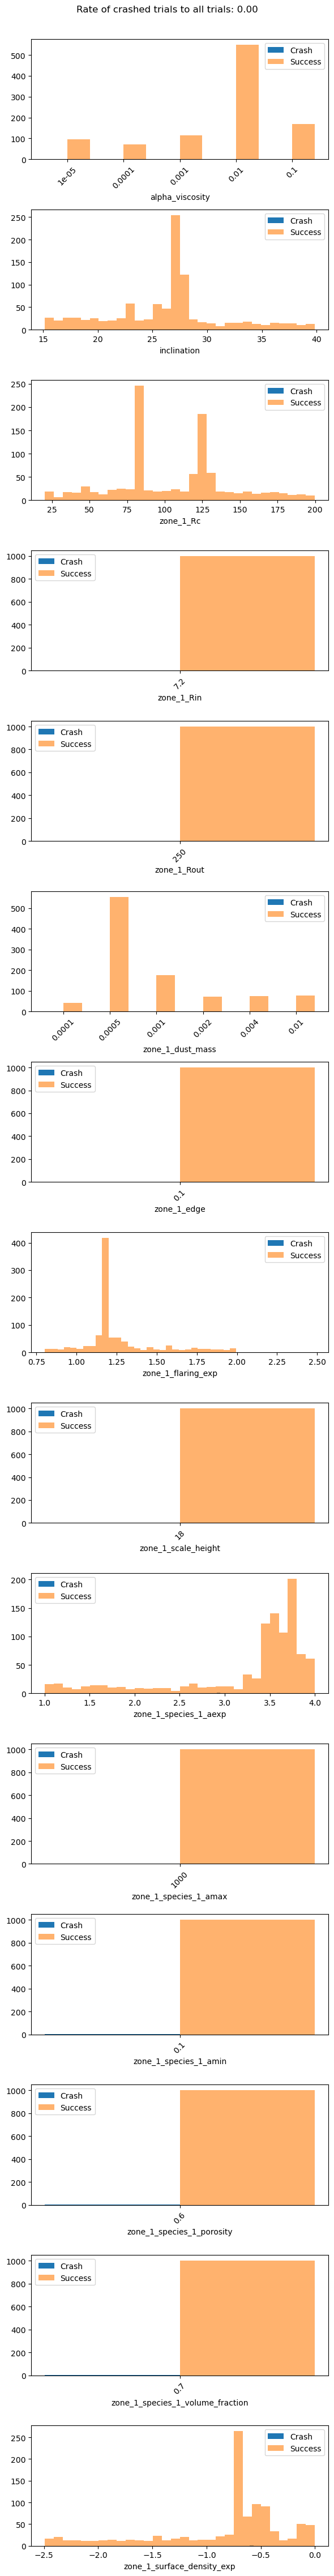

In [6]:
plot_crash_success_histograms(df, crashed_trials, successful_trials, param_cols, results_dir=results_dir, max_unique=20, nbins=30)

### Pairwise sanity checks (parameter vs cost)


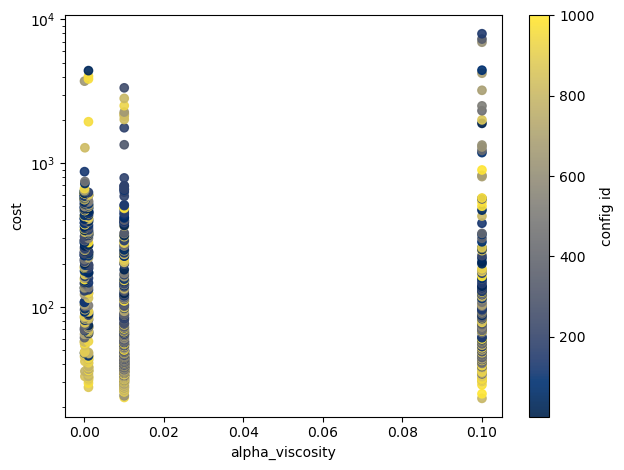

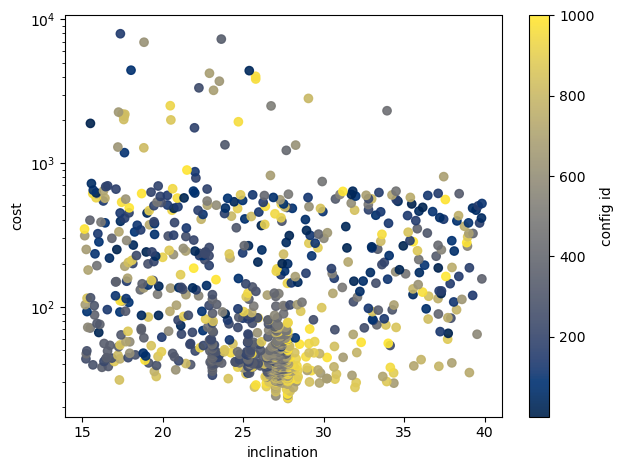

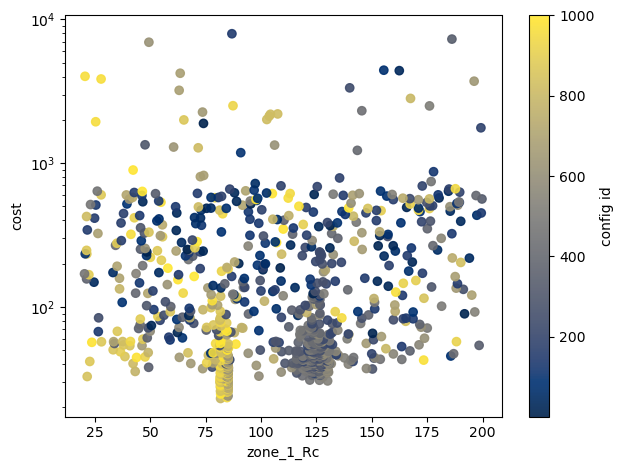

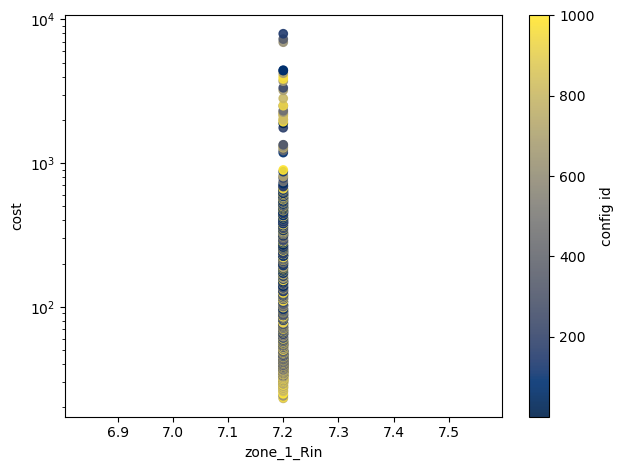

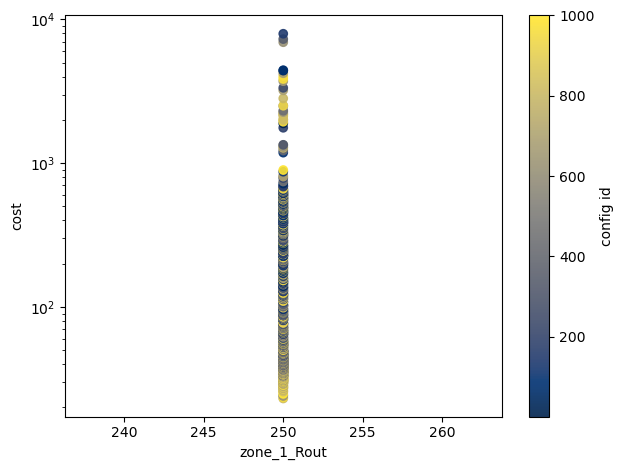

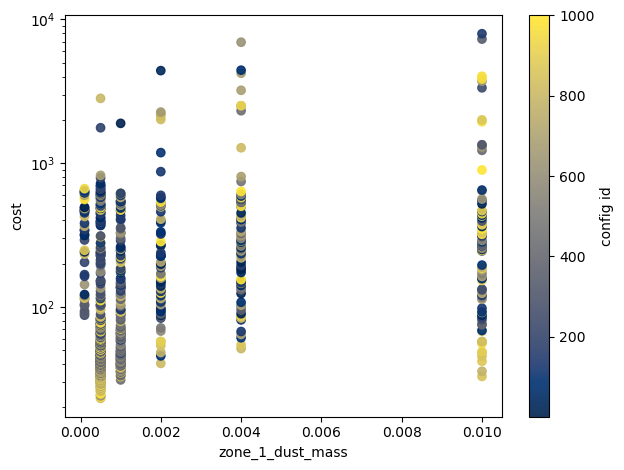

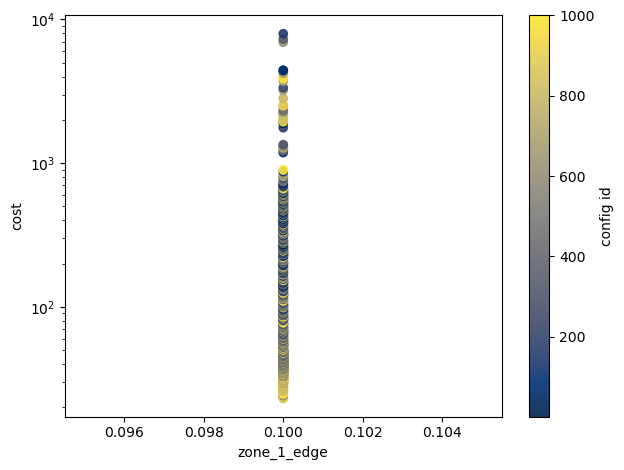

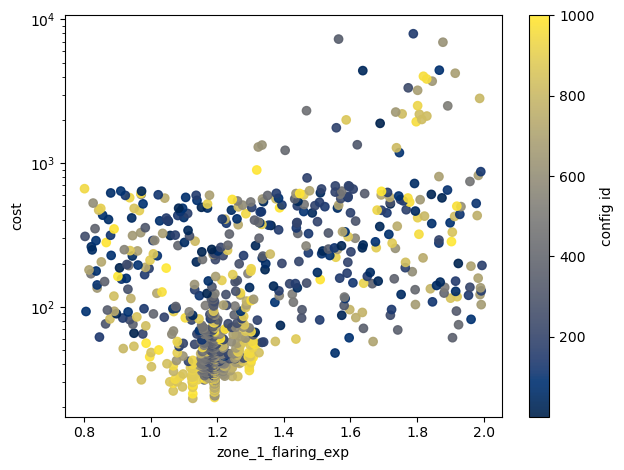

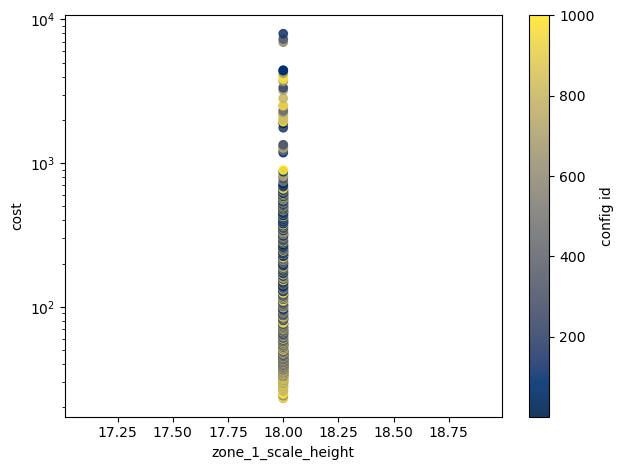

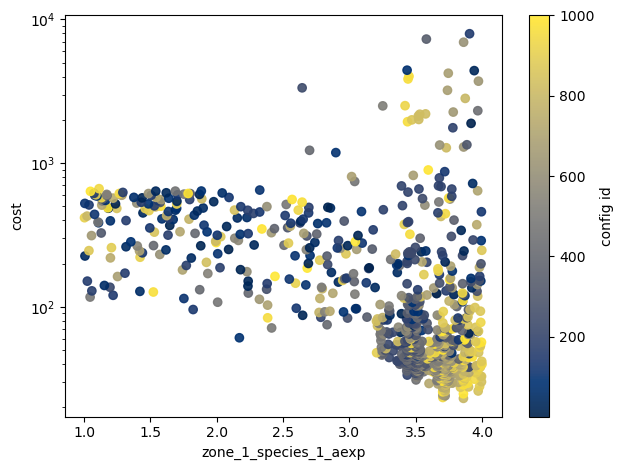

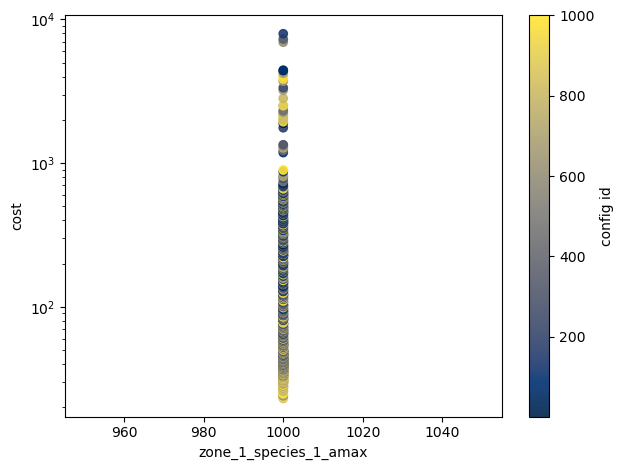

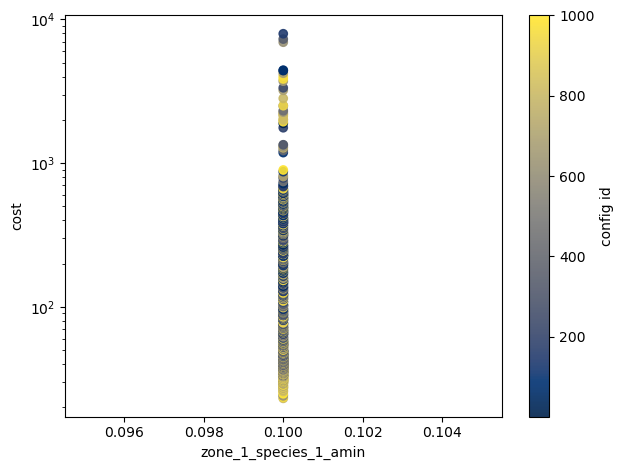

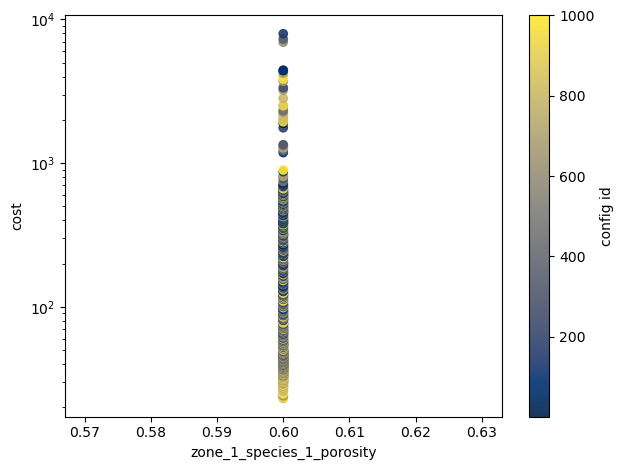

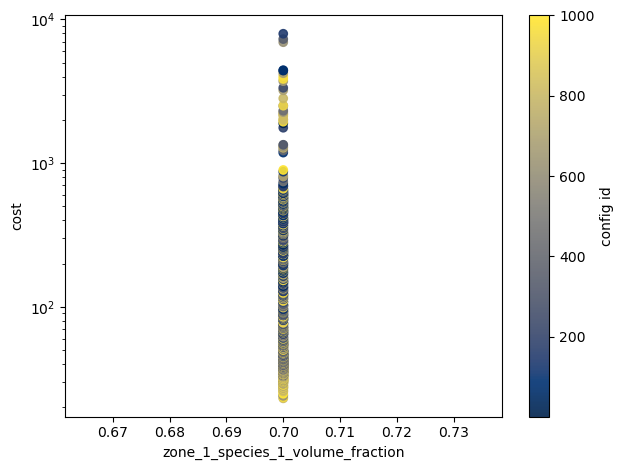

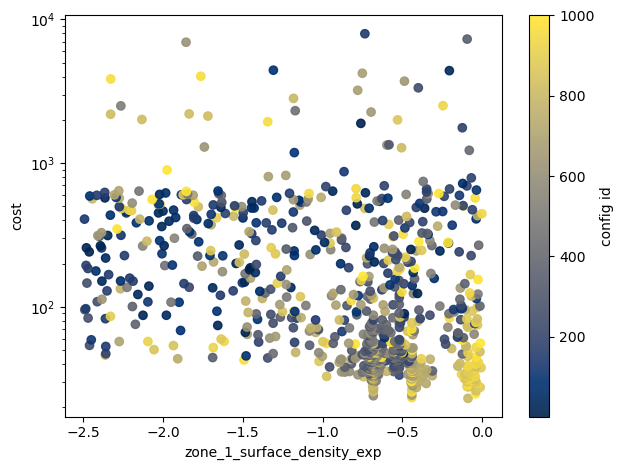

In [7]:


for p in param_cols:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        sc=plt.scatter(successful_trials[p], successful_trials["cost"], c=successful_trials["config_id"], cmap='cividis', alpha=0.9)
        plt.xlabel(p)
        plt.ylabel("cost")
        cbar = plt.colorbar(sc)
        cbar.set_label("config id")

        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.savefig(results_dir +f"scatter_{p}.png", dpi=150)
        plt.show()
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [8]:
successful_trials.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
0.1,999.0,232.041248,598.901662,23.081508,39.45502,57.490817,212.15189,7951.899983


### Parameter importance (fast, practical)

In [9]:
def binned_medians(successful_trials, param, bins=2):
    s = successful_trials[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in successful_trials.columns:
        bm = binned_medians(successful_trials[successful_trials["budget"] == successful_trials["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(20.224999999999998, 106.082]    55.773201
(106.082, 199.754]               59.180614
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(0.801, 1.193]     44.047676
(1.193, 1.995]    136.759788
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(-0.0009, 0.0005]     43.622510
(0.0005, 0.01]       137.686298
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
Series([], Name: cost, dtype: float64)


### Clustering of “good” solutions (degeneracies)

In [10]:

percent_of_successful = len(successful_trials)*0.1

good = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].nsmallest(int(percent_of_successful), "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amax,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time
count,99.000000,99.0,99.000000,99.000000,9.900000e+01,99.0,99.0,99.000000,9.900000e+01,99.000000,...,99.0,9.900000e+01,9.900000e+01,9.900000e+01,99.000000,99.000000,99.0,9.900000e+01,99.000000,99.000000
mean,0.018355,1220.0,27.560713,86.786105,7.200000e+00,250.0,100.0,0.000616,1.000000e-01,1.172253,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.453190,768.949495,680879767.0,1.000000e-01,30.632807,163.216300
std,0.027619,0.0,2.115770,13.233661,6.248889e-15,0.0,0.0,0.000958,1.952778e-16,0.042886,...,0.0,1.952778e-16,1.004286e-15,1.339048e-15,0.249466,148.809588,0.0,1.952778e-16,2.522735,28.244324
min,0.000100,1220.0,17.319422,21.433165,7.200000e+00,250.0,100.0,0.000500,1.000000e-01,0.972365,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.974781,196.000000,680879767.0,1.000000e-01,23.081508,97.268256
25%,0.010000,1220.0,27.032482,82.262823,7.200000e+00,250.0,100.0,0.000500,1.000000e-01,1.163112,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.682097,676.500000,680879767.0,1.000000e-01,29.562635,145.539726
50%,0.010000,1220.0,27.448735,84.780659,7.200000e+00,250.0,100.0,0.000500,1.000000e-01,1.191844,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.441121,792.000000,680879767.0,1.000000e-01,31.215562,163.976173
75%,0.010000,1220.0,27.778180,85.079599,7.200000e+00,250.0,100.0,0.000500,1.000000e-01,1.192506,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.331838,885.000000,680879767.0,1.000000e-01,32.653046,184.942345
max,0.100000,1220.0,34.368308,130.035993,7.200000e+00,250.0,100.0,0.010000,1.000000e-01,1.261809,...,1000.0,1.000000e-01,6.000000e-01,7.000000e-01,-0.012084,995.000000,680879767.0,1.000000e-01,33.749351,219.814480


### Plot

In [11]:
curve = successful_trials.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,0.1,1891.487183
1,3,0.1,520.692057
2,4,0.1,186.840479
3,5,0.1,250.879603
4,6,0.1,368.492316
...,...,...,...
994,996,0.1,489.107167
995,997,0.1,186.078607
996,998,0.1,284.530298
997,999,0.1,67.881181


## For the cornerplot


SMAC does not give a true posterior.
This corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.
So... distribution of high-performing models:

In [12]:
# Restrict to highest fidelity
df_max = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [13]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref"}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['alpha_viscosity',
 'inclination',
 'zone_1_Rc',
 'zone_1_Rin',
 'zone_1_Rout',
 'zone_1_dust_mass',
 'zone_1_edge',
 'zone_1_flaring_exp',
 'zone_1_scale_height',
 'zone_1_species_1_aexp',
 'zone_1_species_1_amax',
 'zone_1_species_1_amin',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

ValueError: It looks like the parameter(s) in column(s) 3, 4, 6, 8, 10, 11, 12, 13 have no dynamic range. Please provide a `range` argument.

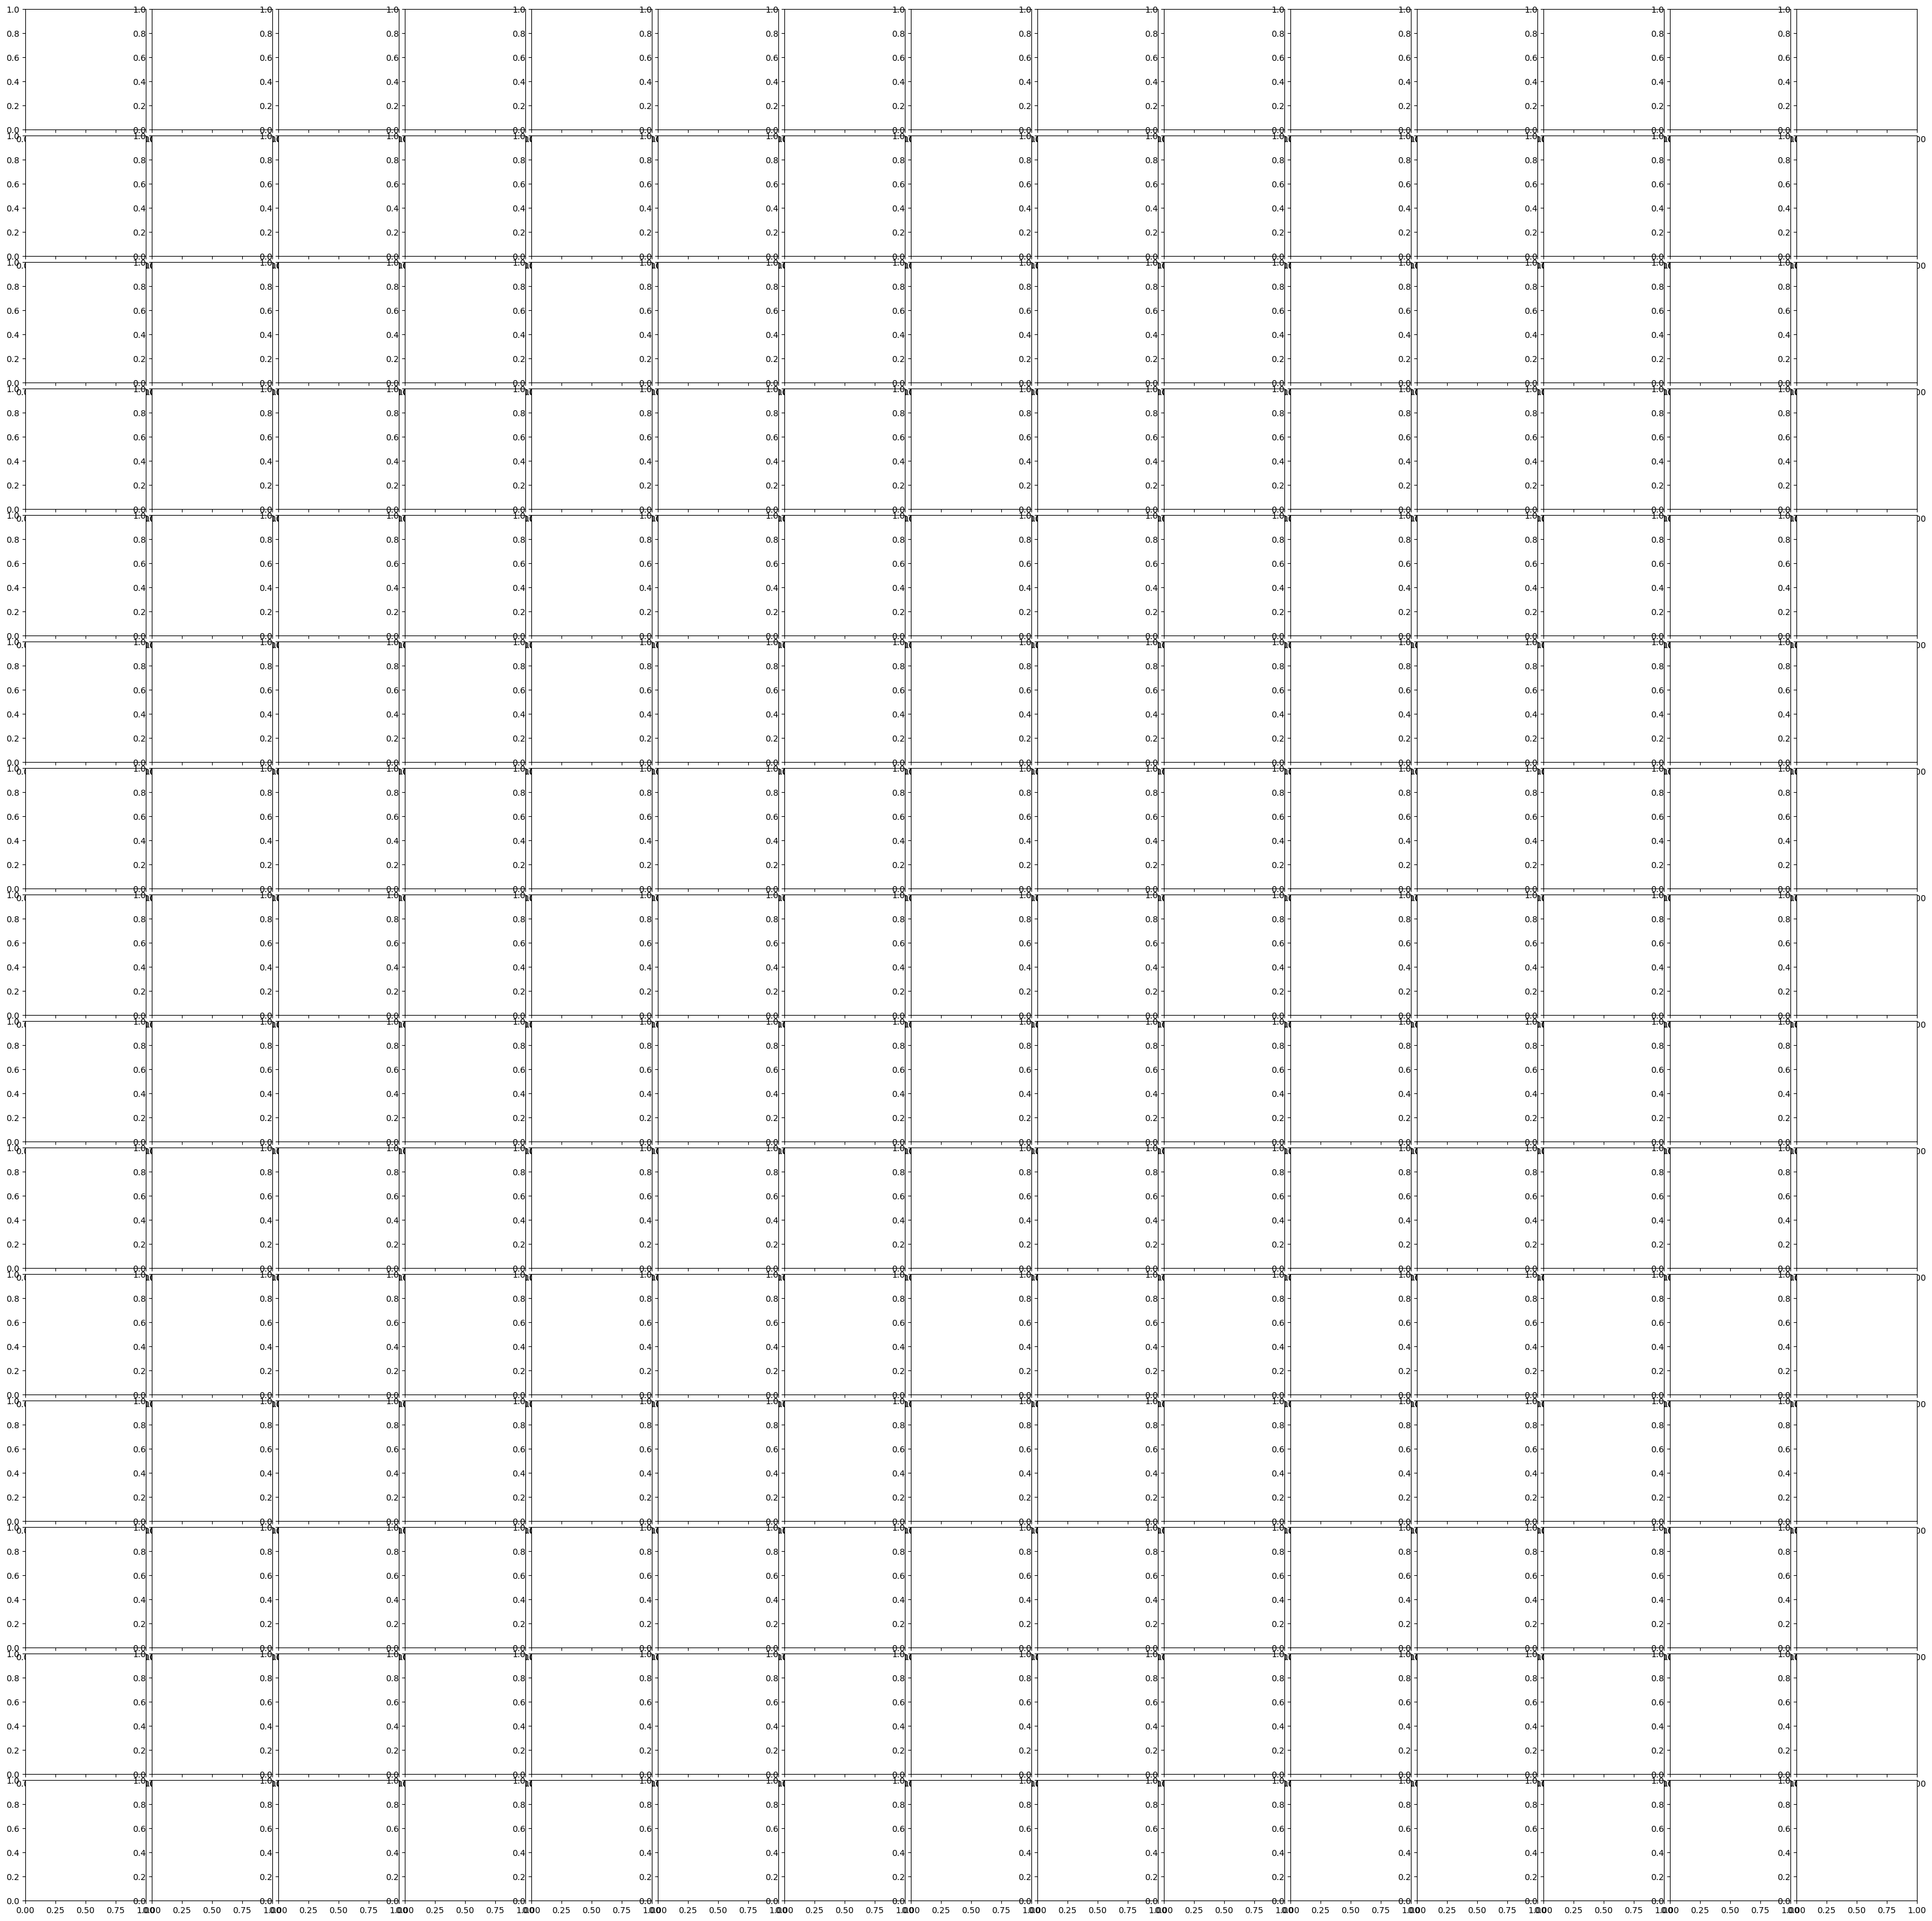

In [14]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

fig.savefig(results_dir +"corner_all_params.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)
fig.savefig(results_dir +"corner_all_params_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



In [33]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    title=None,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]
    if len(d) == 0:
        print("No data to plot after filtering by budget and cost quantile.")
        return
    params_corner = []
    for p in params:
        if p not in d.columns:
            raise ValueError(f"Parameter '{p}' not found in DataFrame columns.")
        if d[p].unique().size >= 2:
            params_corner.append(p)
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")


    if len(params_corner) == 0:
        print("No valid parameters to plot after filtering.")
        return
    data = d[params_corner].values

    fig = corner.corner(
        data,
        labels=params_corner,
        quantiles=[0.16, 0.5, 0.84],
        weights=1.0 / d["cost"].values,
        show_titles=True,
        wrap_title_quantiles=True,
        title_fmt=".3g"  
    )
    plt.suptitle(title, fontsize=14, y=1.01)
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)




        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  899.000000          899.000000        899.000000   
mean   104.678795            1.243142          0.001515   
std     35.621190            0.213209          0.002419   
min     20.225823            0.803349          0.000100   
25%     83.832420            1.173716          0.000500   
50%    106.680720            1.192189          0.000500   
75%    126.553341            1.256595          0.001000   
max    199.432081            1.994575          0.010000   

       zone_1_species_1_porosity  
count               8.990000e+02  
mean                6.000000e-01  
std                 9.997569e-15  
min                 6.000000e-01  
25%                 6.000000e-01  
50%                 6.000000e-01  
75%                 6.000000e-01  
max                 6.000000e-01  
Parameter 'zone_1_species_1_porosity' has less than 2 unique values in the filtered DataFrame.


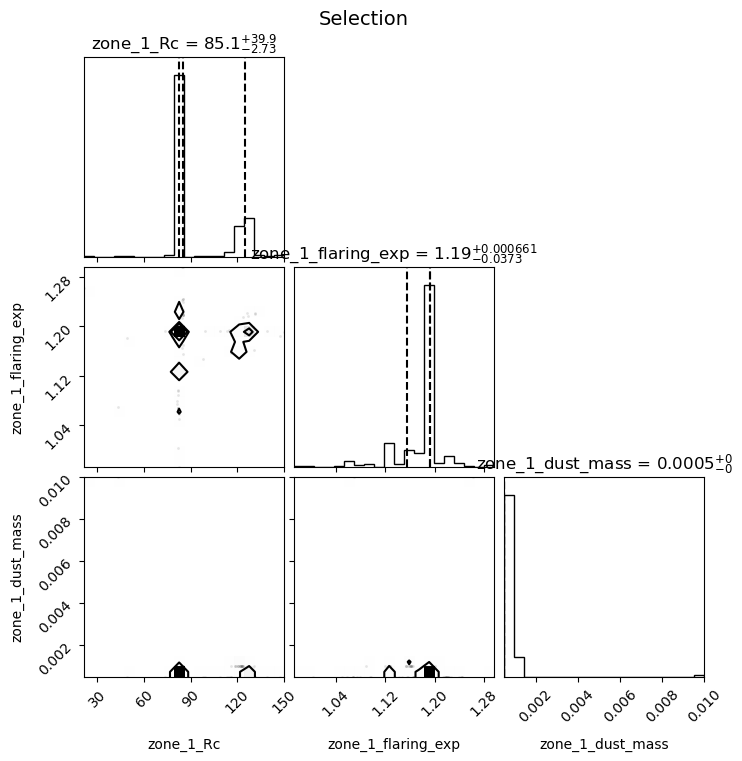

In [34]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df_sel,
    params=param_cols,
    budget=df_sel["budget"].max(),
    outfile=results_dir+ "corner_best.png",
    title="Selection"
)


## setting up subgroups of parameters for corner plots

Parameters for 'Grid setup parameters': []
[]
Parameters for 'Disk orientation parameters': ['distance_pc']
Parameter 'distance_pc' has less than 2 unique values in the filtered DataFrame.
[]
Parameters for 'Disk geometry parameters': ['zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_Rref', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_surface_density_exp']
Parameter 'zone_1_Rin' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rout' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rref' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_edge' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_scale_height' has less than 2 unique values in the filtered DataFrame.
['zone_1_Rc', 'zone_1_flaring_exp', 'zone_1_surface_density_exp']
Corner plot for Disk geometry parameters:


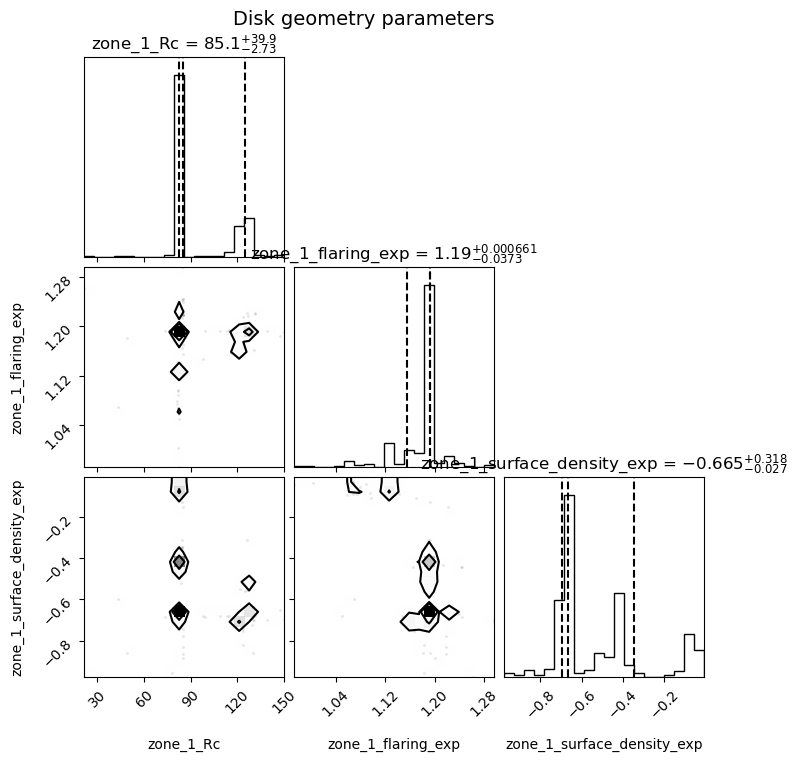

Parameters for 'Dust distribution parameters': ['alpha_viscosity', 'zone_1_dust_mass']
['alpha_viscosity', 'zone_1_dust_mass']
Corner plot for Dust distribution parameters:


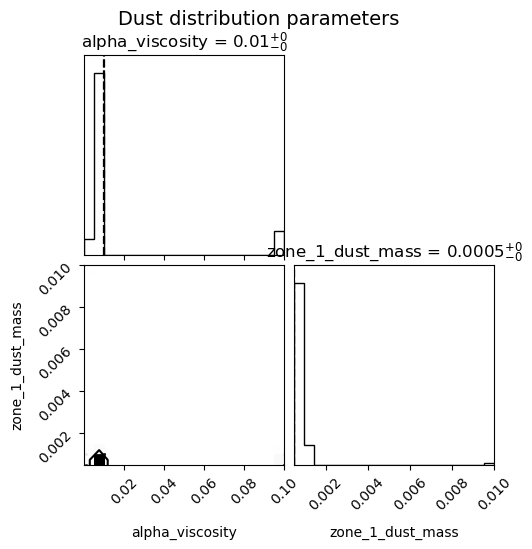

Parameters for 'Dust grain parameters': ['zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction']
Parameter 'zone_1_species_1_amax' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_amin' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_porosity' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_volume_fraction' has less than 2 unique values in the filtered DataFrame.
['zone_1_species_1_aexp']
Parameters for 'Star parameters': []
[]


In [35]:
#all parameters

grid_setup_parameters=["grid_geometry", "n_rad", "nz", "n_az", "n_rad_in", "grid_nx", "grid_ny", "grid_size"]
disk_orientation_parameters=["imin", "imax", "n_incl", "centered", "az_min", "az_max", "distance_pc", "disk_pa"]
disk_geometry_parameters=["zone_1_scale_height", "zone_1_Rref", "zone_1_vertical_profile_exponent", "zone_1_Rin", "zone_1_edge", "zone_1_Rout", "zone_1_Rc", "zone_1_flaring_exp", "zone_1_surface_density_exp", "zone_1_-gamma_exp"]
dust_distribution_parameters=["dust_settling", "exp_strat", "a_strat", "dust_radial_migration", "sublimate_dust", "hydrostatic_equilibrium", "viscous_heating", "alpha_viscosity",
                          "zone_1_dust_mass", "zone_1_gas_to_dust"]
dust_grain_parameters=["zone_1_species_1_grain_type", "zone_1_species_1_N_components", "zone_1_species_1_mixing_rule", "zone_1_species_1_porosity", "zone_1_species_1_mass_fraction", "zone_1_species_1_Vmax", "zone_1_species_1_optical_indices_file", "zone_1_species_1_volume_fraction", "zone_1_species_1_heating_method",
                       "zone_1_species_1_amin", "zone_1_species_1_amax", "zone_1_species_1_aexp", "zone_1_species_1_n_grains"]
star_parameters=["star_1_Temp", "star_1_R", "star_1_M", "star_1_x", "star_1_y", "star_1_z", "star_1_autometic_spectrum", "star_1_spectrum_file", "star_1_fUV", "star_1_slope_fUV"]  


titles={"Grid setup parameters": grid_setup_parameters,
        "Disk orientation parameters": disk_orientation_parameters,
        "Disk geometry parameters": disk_geometry_parameters,
        "Dust distribution parameters": dust_distribution_parameters,
        "Dust grain parameters": dust_grain_parameters,
        "Star parameters": star_parameters}

for title in titles.keys():
    param_subset = titles[title]
    param_cols_set = [c for c in df_sel.columns if c in param_subset]
    param_cols_corner = []  # Initialize a list to keep track of parameters with less than 2 unique values
    print(f"Parameters for '{title}': {param_cols_set}")
    for p in param_cols_set:
        if df_sel[p].unique().size >= 2:
            param_cols_corner.append(p) 
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")

    print(param_cols_corner)

    if len(param_cols_corner)>1:
        print(f"Corner plot for {title}:")
        
        #print(df_sel[param_cols_set].describe())

        make_corner_plot(
            df_sel,
            params=param_cols_corner,
            budget=df_sel["budget"].max(),
            title=title,
            outfile=results_dir+ f"corner_{title}_best.png"
        )

